In [ ]:
import sklearn
# datasetlerimiz bunların üzerinden eğitim yapılacak
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
# sınıflandırma algoritmaları hepsi burada
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
# Model performansını ölçmek için
from sklearn.metrics import accuracy_score ,f1_score
# veri ön işleme için
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [10]:
dataset = load_breast_cancer()

In [15]:
dataset.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [17]:
dataset.target_names
dataset.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [18]:
test_x, train_x, test_y, train_y = train_test_split(dataset.data, dataset.target, test_size=0.2)

In [21]:
# verileri inceledik ve eğitim ve test olarak ayırdık
# şimdi modelimizi seçip eğitime başlayabiliriz

# verileri ölçeklendirelim bu verileri ortalamasını 0 yapar ve standart sapmasını 1 yapacak
# şekilde ölçeklendirir böylelikle her özelliği standartlaştırır
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

model = LogisticRegression(max_iter=500)
model.fit(train_x_scaled, train_y)
predictions = model.predict(test_x_scaled)
accuracy = accuracy_score(test_y, predictions)
f1 = f1_score(test_y, predictions)
print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")

Accuracy: 0.9560439560439561
F1 Score: 0.9658703071672355


In [ ]:
# Gradient Boosting ve Neural Network algoritmaları için gerekli kütüphaneler


# XGBoost
model_xgb = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)
model_xgb.fit(train_x_scaled, train_y)
predictions_xgb = model_xgb.predict(test_x_scaled)
accuracy_xgb = accuracy_score(test_y, predictions_xgb)
f1_xgb = f1_score(test_y, predictions_xgb)

# LightGBM
model_lgbm = LGBMClassifier()
model_lgbm.fit(train_x_scaled, train_y)
predictions_lgbm = model_lgbm.predict(test_x_scaled)
accuracy_lgbm = accuracy_score(test_y, predictions_lgbm)
f1_lgbm = f1_score(test_y, predictions_lgbm)

# CatBoost
model_cat = CatBoostClassifier(verbose=0)
model_cat.fit(train_x_scaled, train_y)
predictions_cat = model_cat.predict(test_x_scaled)
accuracy_cat = accuracy_score(test_y, predictions_cat)
f1_cat = f1_score(test_y, predictions_cat)

# Multilayer Perceptron (MLP)
model_mlp = MLPClassifier(max_iter=500)
model_mlp.fit(train_x_scaled, train_y)
predictions_mlp = model_mlp.predict(test_x_scaled)
accuracy_mlp = accuracy_score(test_y, predictions_mlp)
f1_mlp = f1_score(test_y, predictions_mlp)

# Sonuçları tablo olarak göster
results_cancer_ensemble = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost', 'MLP'],
    'Accuracy': [accuracy_xgb, accuracy_lgbm, accuracy_cat, accuracy_mlp],
    'F1 Score': [f1_xgb, f1_lgbm, f1_cat, f1_mlp]
})
print(results_cancer_ensemble)

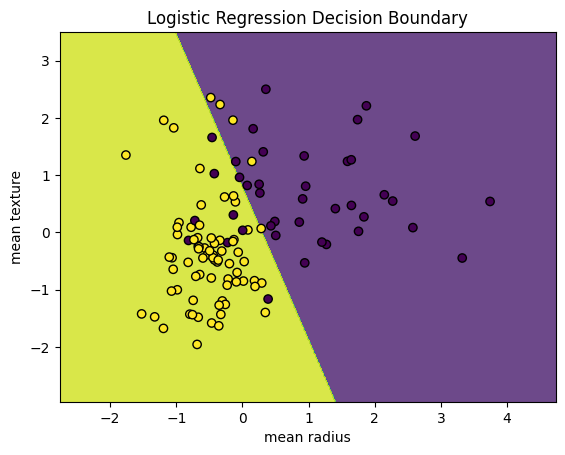

In [25]:
# logisctic regression ile %96 doğruluk elde ettik
# şimdi modelin grafini çizdirelim logistic regressionun o S şeklindeki grafiğini görelim
# şimdi grafiği çizdirelim
import matplotlib.pyplot as plt
import numpy as np
# Sadece ilk iki özelliği kullanarak grafiği çizdirelim
X = train_x_scaled[:, :2]
y = train_y
model_2d = LogisticRegression(max_iter=500)
model_2d.fit(X, y)
# Grafik sınırlarını belirleyelim
x_min, x_max = X[:, 0].min() - 1, X[:,
    0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01
), np.arange(y_min, y_max, 0.01))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.xlabel(dataset.feature_names[0])
plt.ylabel(dataset.feature_names[1])
plt.title('Logistic Regression Decision Boundary')
plt.show()


In [26]:
# şimdi diğer algoritmaları deneyelim ve sonuçları karşılaştıralım
# linear regression
model_lr = LinearRegression()
model_lr.fit(train_x_scaled, train_y)
predictions_lr = model_lr.predict(test_x_scaled)
# linear regression sürekli değerler döndürdüğü için 0.5 ten büyükse 1 değilse 0 yapalım
predictions_lr = [1 if p > 0.5 else 0 for p in predictions_lr]
accuracy_lr = accuracy_score(test_y, predictions_lr)
f1_lr = f1_score(test_y, predictions_lr)
print(f"Linear Regression Accuracy: {accuracy_lr}")
print(f"Linear Regression F1 Score: {f1_lr}")

Linear Regression Accuracy: 0.9318681318681319
Linear Regression F1 Score: 0.9478991596638655


In [27]:
# F1 score ve accuracy score değerleri logistic regressiondan düşük çıktı
# şimdi decision tree deneyelim
model_dt = DecisionTreeClassifier()
model_dt.fit(train_x_scaled, train_y)
predictions_dt = model_dt.predict(test_x_scaled)
accuracy_dt = accuracy_score(test_y, predictions_dt)
f1_dt = f1_score(test_y, predictions_dt)
print(f"Decision Tree Accuracy: {accuracy_dt}")
print(f"Decision Tree F1 Score: {f1_dt}")

Decision Tree Accuracy: 0.9032967032967033
Decision Tree F1 Score: 0.9230769230769231


In [28]:
# decision tree de linear regressiondan düşük çıktı
# şimdi random forest deneyelim
model_rf = RandomForestClassifier()
model_rf.fit(train_x_scaled, train_y)
predictions_rf = model_rf.predict(test_x_scaled)
accuracy_rf = accuracy_score(test_y, predictions_rf)
f1_rf = f1_score(test_y, predictions_rf)
print(f"Random Forest Accuracy: {accuracy_rf}")
print(f"Random Forest F1 Score: {f1_rf}")

Random Forest Accuracy: 0.9406593406593406
Random Forest F1 Score: 0.9525483304042179


In [29]:
# fena değil logisctic regressiondan biraz düşük ama decision tree ve linear regressiondan iyi çıktı
# şimdi knn deneyelim
model_knn = KNeighborsClassifier()
model_knn.fit(train_x_scaled, train_y)
predictions_knn = model_knn.predict(test_x_scaled)
accuracy_knn = accuracy_score(test_y, predictions_knn)
f1_knn = f1_score(test_y, predictions_knn)
print(f"KNN Accuracy: {accuracy_knn}")
print(f"KNN F1 Score: {f1_knn}")

KNN Accuracy: 0.9494505494505494
KNN F1 Score: 0.9605488850771869


In [30]:
# KNN de logisctic regressiondan düşük çıktı
# SVC deneyelim
model_svc = SVC()
model_svc.fit(train_x_scaled, train_y)
predictions_svc = model_svc.predict(test_x_scaled)
accuracy_svc = accuracy_score(test_y, predictions_svc)
f1_svc = f1_score(test_y, predictions_svc)
print(f"SVC Accuracy: {accuracy_svc}")
print(f"SVC F1 Score: {f1_svc}")

SVC Accuracy: 0.9560439560439561
SVC F1 Score: 0.9655172413793104


In [31]:
# şimdi bütün sonuçları bir arada görelim
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVC'],
    'Accuracy': [accuracy, accuracy_lr, accuracy_dt, accuracy_rf, accuracy_knn, accuracy_svc],
    'F1 Score': [f1, f1_lr, f1_dt, f1_rf, f1_knn, f1_svc]
})
print(results)


                 Model  Accuracy  F1 Score
0  Logistic Regression  0.956044  0.965870
1    Linear Regression  0.931868  0.947899
2        Decision Tree  0.903297  0.923077
3        Random Forest  0.940659  0.952548
4                  KNN  0.949451  0.960549
5                  SVC  0.956044  0.965517


In [32]:
# şimdi bunların hepsini iris dataseti ile de deneyelim ve daha sonra neden bu sonuçları aldığımızı
# inceleyelim ve sebeplerini açıklayalım
dataset = load_iris()
dataset.feature_names
dataset.target_names
dataset.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [33]:
dataset.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [34]:
# irisi yükledik şimdi makine öğrenmesi algoritmalarını deneyelim
test_x, train_x, test_y, train_y = train_test_split(dataset.data, dataset.target, test_size=0.2)

In [35]:
# verileri ayırdık şimdi ölçeklendirelim
scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)


In [36]:
# şimdi makine öğrenmesi algoritmalarını deneyelim
LogisticRegression = LogisticRegression(max_iter=500)
LogisticRegression.fit(train_x_scaled, train_y)
predictions = LogisticRegression.predict(test_x_scaled)
accuracy = accuracy_score(test_y, predictions)
f1 = f1_score(test_y, predictions, average='macro')
print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")


Accuracy: 0.9666666666666667
F1 Score: 0.967032967032967


In [37]:
# Diğer algoritmalar: Linear Regression, Decision Tree, Random Forest, KNN, SVC
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Linear Regression
model_lr = LinearRegression()
model_lr.fit(train_x_scaled, train_y)
predictions_lr = model_lr.predict(test_x_scaled)
predictions_lr = [round(p) for p in predictions_lr]
accuracy_lr = accuracy_score(test_y, predictions_lr)
f1_lr = f1_score(test_y, predictions_lr, average='macro')

# Decision Tree
model_dt = DecisionTreeClassifier()
model_dt.fit(train_x_scaled, train_y)
predictions_dt = model_dt.predict(test_x_scaled)
accuracy_dt = accuracy_score(test_y, predictions_dt)
f1_dt = f1_score(test_y, predictions_dt, average='macro')

# Random Forest
model_rf = RandomForestClassifier()
model_rf.fit(train_x_scaled, train_y)
predictions_rf = model_rf.predict(test_x_scaled)
accuracy_rf = accuracy_score(test_y, predictions_rf)
f1_rf = f1_score(test_y, predictions_rf, average='macro')

# KNN
model_knn = KNeighborsClassifier()
model_knn.fit(train_x_scaled, train_y)
predictions_knn = model_knn.predict(test_x_scaled)
accuracy_knn = accuracy_score(test_y, predictions_knn)
f1_knn = f1_score(test_y, predictions_knn, average='macro')

# SVC
model_svc = SVC()
model_svc.fit(train_x_scaled, train_y)
predictions_svc = model_svc.predict(test_x_scaled)
accuracy_svc = accuracy_score(test_y, predictions_svc)
f1_svc = f1_score(test_y, predictions_svc, average='macro')

# Sonuçları tablo olarak göster
results_iris = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVC'],
    'Accuracy': [accuracy, accuracy_lr, accuracy_dt, accuracy_rf, accuracy_knn, accuracy_svc],
    'F1 Score': [f1, f1_lr, f1_dt, f1_rf, f1_knn, f1_svc]
})
print(results_iris)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.966667  0.967033
1    Linear Regression  0.958333  0.958747
2        Decision Tree  0.966667  0.966830
3        Random Forest  0.958333  0.958442
4                  KNN  0.875000  0.875327
5                  SVC  0.933333  0.934344


In [ ]:
# Gradient Boosting ve Neural Network algoritmaları için gerekli kütüphaneler


# XGBoost
model_xgb = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)
model_xgb.fit(train_x_scaled, train_y)
predictions_xgb = model_xgb.predict(test_x_scaled)
accuracy_xgb = accuracy_score(test_y, predictions_xgb)
f1_xgb = f1_score(test_y, predictions_xgb, average='macro')

# LightGBM
model_lgbm = LGBMClassifier()
model_lgbm.fit(train_x_scaled, train_y)
predictions_lgbm = model_lgbm.predict(test_x_scaled)
accuracy_lgbm = accuracy_score(test_y, predictions_lgbm)
f1_lgbm = f1_score(test_y, predictions_lgbm, average='macro')

# CatBoost
model_cat = CatBoostClassifier(verbose=0)
model_cat.fit(train_x_scaled, train_y)
predictions_cat = model_cat.predict(test_x_scaled)
accuracy_cat = accuracy_score(test_y, predictions_cat)
f1_cat = f1_score(test_y, predictions_cat, average='macro')

# Multilayer Perceptron (MLP)
model_mlp = MLPClassifier(max_iter=500)
model_mlp.fit(train_x_scaled, train_y)
predictions_mlp = model_mlp.predict(test_x_scaled)
accuracy_mlp = accuracy_score(test_y, predictions_mlp)
f1_mlp = f1_score(test_y, predictions_mlp, average='macro')

# Sonuçları tablo olarak göster
results_iris_ensemble = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost', 'MLP'],
    'Accuracy': [accuracy_xgb, accuracy_lgbm, accuracy_cat, accuracy_mlp],
    'F1 Score': [f1_xgb, f1_lgbm, f1_cat, f1_mlp]
})
print(results_iris_ensemble)

Görüldüğü üzere bir dizi makine öğrenmesi algoritmasını denedik ve sonuçlarını karşılaştırdık
şimdi bu sonuçların neden böyle olduğunu inceleyelim ve sebeplerini açıklayalım
"""
Algoritmaların performans farklılıklarının temel sebepleri:

1. **Veri Setinin Yapısı**: 
   - Breast Cancer ve Iris veri setleri, iyi ayrışan ve dengeli sınıflara sahip. Bu nedenle doğrusal modeller (Logistic Regression) yüksek başarı gösteriyor.
   - Karmaşık ilişkiler veya çok boyutlu verilerde ensemble ve non-linear modeller (Random Forest, XGBoost, MLP) daha iyi performans verebilir.

2. **Modelin Karmaşıklığı**:
   - Basit modeller (Linear/Logistic Regression) hızlı ve genellikle iyi genelleme yapar, ancak karmaşık ilişkileri yakalamakta zorlanabilir.
   - Karar ağaçları ve ansambl modelleri (Random Forest, XGBoost, LightGBM, CatBoost) daha karmaşık yapıları öğrenebilir, ancak aşırı öğrenmeye (overfitting) yatkındır.

3. **Ölçeklendirme ve Ön İşleme**:
   - KNN ve SVC gibi algoritmalar, özelliklerin ölçeklendirilmesinden doğrudan etkilenir. Standartlaştırma yapılmazsa performansları düşer.

4. **Veri Setinin Boyutu ve Dengesizliği**:
   - Küçük veri setlerinde karmaşık modeller aşırı öğrenme yapabilir.
   - Sınıf dengesizliği varsa F1 skoru accuracy'den daha anlamlıdır.

5. **Modelin Varsayımları**:
   - Linear Regression, sürekli değerler için uygundur; sınıflandırmada threshold ile sınıf tahmini yapılır, bu nedenle doğruluğu düşebilir.
   - Logistic Regression, iki veya daha fazla sınıfı iyi ayırabilen doğrusal bir sınıflandırıcıdır.

**Genel Sonuç:**
- Logistic Regression ve SVC gibi doğrusal modeller, iyi ayrışan veri setlerinde yüksek başarı gösterir.
- Ensemble ve neural network tabanlı modeller, karmaşık ve büyük veri setlerinde avantaj sağlar.
- Her algoritmanın performansı, veri setinin yapısına, boyutuna ve özelliklerine bağlı olarak değişir.

Daha fazla veri ve farklı veri setleriyle testler yaparak, algoritmaların avantaj ve dezavantajlarını daha net görebilirsiniz.
"""

### Model Karşılaştırma Notları

- **Logistic Regression**: Sınıflar iyi ayrışıyorsa ve veri doğrusal ise en yüksek başarıyı verir. Breast Cancer ve Iris veri setlerinde genellikle en iyi sonuç.
- **Random Forest / XGBoost / LightGBM / CatBoost**: Karmaşık ilişkiler ve çok boyutlu veri için uygundur. Büyük veri setlerinde ve karmaşık yapıda daha iyi performans gösterir.
- **KNN / SVC**: Özellikler iyi ölçeklendirilirse başarılıdır. Küçük ve iyi ayrışan veri setlerinde yüksek doğruluk sağlar.
- **MLP (Neural Network)**: Özellikle çok karmaşık ve büyük veri setlerinde avantajlıdır, ancak küçük veri setlerinde aşırı öğrenme yapabilir.
- **Linear Regression**: Sınıflandırma için uygun değildir, doğruluğu düşüktür. Sürekli değer tahmini için kullanılır.

> Her modelin performansı veri setinin yapısına, boyutuna ve sınıf ayrışmasına bağlı olarak değişir.